<!-- auditkit-logo-cell -->
<p align="center">
  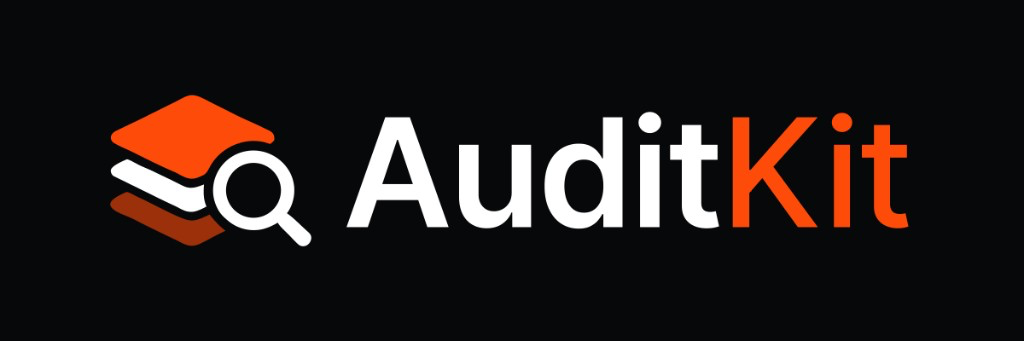
</p>

# AuditKit — performance metrics on a real, large-scale evaluation

**Note (model history):** this notebook has moved through three model setups
across development -- originally Groq-hosted Llama models (removed by Groq),
then Groq-hosted gpt-oss/qwen models, now three real, local, gated/ungated
Hugging Face checkpoints run via `HFGenModel` with an HF token instead of
`GroqModel` with a Groq API key. All model references, labels, and pricing
below are consistent with this final setup. **This notebook has not been
re-executed end to end against it** -- expect to need a real GPU (these are
local models, not a hosted API); re-run before trusting or publishing its
numbers.

**Note (model size):** `meta-llama/Llama-2-13b-chat-hf` is ~26GB in
fp16 -- fits on a single high-memory GPU (e.g. an A100 40GB), tighter
on a Colab T4/L4 without a quantized load (e.g. `load_in_4bit`), which
isn't wired through `HFGenModel` here yet.

**Runs on Google Colab** (needs a GPU runtime now -- these are local
models) — the first two cells below detect Colab and self-install
`auditkit` from source (it isn't on PyPI yet), or skip straight through
if you're already set up locally.

Real models, real dataset, not synthetic stand-ins:

- **Models**: three real, local Hugging Face checkpoints --
  `meta-llama/Llama-3.1-8B-Instruct` (`llama-8b`, gated) and
  `meta-llama/Llama-2-13b-chat-hf` (`llama-13b`, gated) run side by side
  as the base-vs-candidate pair, plus `Qwen/Qwen2.5-14B-Instruct`
  (`qwen-14b`, ungated) as the third model in the N-model comparison --
  an account must accept the two gated models' licenses on
  huggingface.co before its token can load them
- **Dataset**: 25 real sentences from SST-2 (Stanford Sentiment Treebank,
  via `nyu-mll/glue`), loaded straight from HuggingFace

Needs an HF token with the two gated Llama licenses accepted — the setup
cell prompts for it interactively (`getpass`), never hardcoded or
committed anywhere.

In [1]:
# Colab bootstrap -- clones and installs auditkit from source (no PyPI
# package exists yet). No-op outside Colab: if you're already running this
# locally with auditkit installed (e.g. `pip install -e .`), this cell does
# nothing and falls through immediately.
import sys, subprocess, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import getpass
    REPO_DIR = "/content/AuditKit-mirror"
    if not os.path.exists(REPO_DIR):
        github_token = getpass.getpass(
            "GitHub personal access token (repo is private -- needs 'repo' read scope): "
        )
        repo_url = f"https://{github_token}@github.com/utsavavaiya-sudo/AuditKit-mirror.git"
        clone = subprocess.run(
            ["git", "clone", "-b", "continue-removal-branch", "-q", repo_url, REPO_DIR],
            capture_output=True, text=True,
        )
        if clone.returncode != 0:
            # Never let a CalledProcessError propagate here -- its default
            # repr includes process.args, which contains the token embedded
            # in repo_url. Anyone who copy-pastes that traceback (e.g. into
            # a chat) leaks their token. Raise a clean, redacted error instead.
            raise RuntimeError(
                "git clone failed:\n" + clone.stderr.replace(github_token, "<redacted>") +
                "\nCommon causes: token missing 'repo' scope (classic PAT) or "
                "'Contents: Read' permission on this repo (fine-grained PAT), "
                "token not authorized for this org (SSO), or your account isn't "
                "a collaborator on this repo."
            )
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", f"{REPO_DIR}[interop]"], check=True)
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "requests"], check=True)
    if REPO_DIR not in sys.path:
        sys.path.insert(0, f"{REPO_DIR}/src")
    print("Colab detected -- auditkit installed from source at", REPO_DIR)
else:
    print("Not running in Colab -- assuming auditkit is already installed locally.")

Colab detected -- auditkit installed from source at /content/AuditKit-mirror


In [2]:
import os
import getpass
import json

import auditkit as ak
from auditkit import Sample
from auditkit.comparison import RunComparison
from auditkit.model_compare import compare_models
from auditkit.model.hf_gen import HFGenModel
from auditkit.runspec import RunConfig
from auditkit.metric import QuasiExactMatch

# Prompts interactively only if HF_TOKEN isn't already set in the
# environment -- never hardcoded, never written to disk. Needs a token from
# an account that accepted each gated Llama model's license on huggingface.co.
if not os.environ.get("HF_TOKEN"):
    os.environ["HF_TOKEN"] = getpass.getpass("HF token (gated Llama models): ")

print("auditkit version:", ak.__version__)

auditkit version: 0.3.0


## Real dataset — SST-2, 25 real sentences

`nyu-mll/glue`'s `sst2` validation split (test labels aren't public) --
real movie-review sentences with a real binary sentiment label. Prompted
so the model just returns one word, scored with `QuasiExactMatch`
(case/punctuation-insensitive -- a real model reliably answers
`"Positive."`/`"positive"`/`"POSITIVE"` interchangeably).

In [3]:
import datasets as hf_datasets

N = 25
rows = hf_datasets.load_dataset("nyu-mll/glue", "sst2", split=f"validation[:{N}]")

PROMPT_TEMPLATE = (
    "Classify the sentiment of this sentence as exactly one word, "
    "either positive or negative.\n\nSentence: {text}\nLabel:"
)

samples = [
    Sample(input=PROMPT_TEMPLATE.format(text=r["sentence"].strip()),
          target="positive" if r["label"] == 1 else "negative")
    for r in rows
]
print(f"{len(samples)} real SST-2 samples loaded")
print("example:", samples[0].input)
print("target:", samples[0].target)

README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

sst2/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.11MB            

sst2/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sst2/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 72.8kB            

sst2/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

sst2/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

25 real SST-2 samples loaded
example: Classify the sentiment of this sentence as exactly one word, either positive or negative.

Sentence: it 's a charming and often affecting journey .
Label:
target: positive


---
## 1. A single `evaluate()` run — real model, real dataset

`meta-llama/Llama-3.1-8B-Instruct` (`llama-8b`): the smaller of the two
Llama candidates. This is the first real generation call against this
specific model, so its output gets cached under this run's fingerprint
for reuse in Section 2.

In [4]:
config = RunConfig(concurrency=1, max_retries=3, retry_delay=5.0, temperature=0.0, max_tokens=8, track_performance=True)

result = ak.evaluate(
    dataset=samples,
    model=HFGenModel(model="meta-llama/Llama-3.1-8B-Instruct", hf_token=os.environ["HF_TOKEN"], device="cuda"),
    scorers=[QuasiExactMatch()],
    config=config,
    experiment_name="sst2_real_demo",
    tags=["notebook", "real-hf", "sst2"],
)
print(result.summary())

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


run fd99dfabec2a23ea (fingerprint fd99dfabec2a23ea)
  quasi_exact_match: 0.9200 ± 0.0543  (n=25)
  perf: latency=68913ms (n=1 calls) | throughput=0.36 req/s
  model: meta-llama/Llama-3.1-8B-Instruct -- 8,030,261,248 params (0.0% sparse), 15316.5 MB


In [5]:
print(json.dumps({
    "headline": result.headline,
    "perf": result.perf,
    "model_size": result.model_size,
    "token_usage": result.token_usage,
}, indent=2))

{
  "headline": {
    "quasi_exact_match": 0.92
  },
  "perf": {
    "latency_ms": {
      "count": 1,
      "mean": 68913.12953599982,
      "min": 68913.12953599982,
      "max": 68913.12953599982,
      "p50": 68913.12953599982,
      "p95": 68913.12953599982,
      "p99": 68913.12953599982,
      "std": 0.0
    },
    "throughput": {
      "rps": 0.36277557220703704,
      "total_requests": 25,
      "total_time_ms": 68913.12953599982,
      "output_tokens_per_sec": 0.0,
      "total_tokens_per_sec": 0.0
    }
  },
  "model_size": {
    "is_local": true,
    "model_name": "meta-llama/Llama-3.1-8B-Instruct",
    "total_params": 8030261248,
    "nonzero_params": 8030259962,
    "sparsity": 1.6014422943300133e-07,
    "size_mb": 15316.5078125
  },
  "token_usage": {
    "prompt_tokens": 0,
    "completion_tokens": 0,
    "total_tokens": 0
  }
}


---
## 2. `RunComparison` — real baseline vs. real candidate, same dataset

`meta-llama/Llama-3.1-8B-Instruct` (`llama-8b`, reused from Section 1's
cached run -- identical fingerprint, no new generation call) vs.
`meta-llama/Llama-2-13b-chat-hf` (`llama-13b`, larger -- its own first,
and only, real generation call here). A genuine quality/latency/cost
tradeoff between two real, differently-sized models on identical real
data.

In [6]:
baseline = ak.evaluate(samples, model=HFGenModel(model="meta-llama/Llama-3.1-8B-Instruct", hf_token=os.environ["HF_TOKEN"], device="cuda"),
                       scorers=[QuasiExactMatch()], config=config)
candidate = ak.evaluate(samples, model=HFGenModel(model="meta-llama/Llama-2-13b-chat-hf", hf_token=os.environ["HF_TOKEN"], device="cuda"),
                        scorers=[QuasiExactMatch()], config=config)

cmp = RunComparison(baseline, candidate, pass_threshold=0.02, warn_threshold=0.05)
print(cmp.summary())

config.json:   0%|          | 0.00/587 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/33.4k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/363 [00:00<?, ?it/s]

...

tokenizer.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer LlamaTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Comparison: fd99dfabec2a23ea (baseline) -> b6b64a38e1cd7bdc (candidate)
  per-metric (baseline -> candidate | absolute delta | relative %):
    quasi_exact_match: 0.9200 -> 0.5200  delta=-0.4000 (-43.5% rel)  (n=25->25, std=0.2713->0.4996)
  samples: 10 went correct->wrong, 0 went wrong->correct
  performance: latency 68913ms -> 78611ms, throughput 0.36 -> 0.32 req/s (speedup=0.88x)
  model size: 15316.5 MB -> 24825.8 MB (meta-llama/Llama-3.1-8B-Instruct -> meta-llama/Llama-2-13b-chat-hf)


In [7]:
print("grade():        ", cmp.grade())
print("retention():    ", cmp.retention("quasi_exact_match"))
print("significance(): ", cmp.significance("quasi_exact_match"))
print("regressed():    ", len(cmp.regressed()), "samples")
print("improved():     ", len(cmp.improved()), "samples")
print()
print("tradeoff() -- real measured latency, real token-driven cost inputs:")
print(json.dumps(cmp.tradeoff(), indent=2, default=str))

grade():         DeltaGrade.FAIL
retention():     0.5652173913043478
significance():  {'n': 25, 'mean_baseline': 0.92, 'mean_candidate': 0.52, 'delta': -0.4, 'p_value': 0.569431, 'significant': False}
regressed():     10 samples
improved():      0 samples

tradeoff() -- real measured latency, real token-driven cost inputs:
{
  "metric": "quasi_exact_match",
  "baseline_quality": 0.92,
  "candidate_quality": 0.52,
  "retention": 0.5652173913043478,
  "baseline_size_mb": 15316.5078125,
  "candidate_size_mb": 24825.791015625,
  "size_ratio": 1.620851914779448,
  "quality_per_mb": 2.27673467060368e-05,
  "baseline_latency_ms": 68913.12953599982,
  "candidate_latency_ms": 78610.53836099996,
  "latency_ratio": 1.1407193214165998,
  "speedup": 0.8766398370092936
}


### Real cost — illustrative pricing, real token counts

Real token counts (from `cmp.baseline.token_usage`/`cmp.candidate.token_usage`,
measured from the actual local generations) times **illustrative** pricing
figures -- these two models run locally, not through a metered API, so
there is no real per-token bill to report; the library never bundles a
pricing table so you always supply current numbers yourself, hosted or not.

In [8]:
cost = cmp.cost(
    baseline_pricing={"input_per_1m": 0.05, "output_per_1m": 0.08},   # llama-8b, illustrative
    candidate_pricing={"input_per_1m": 0.59, "output_per_1m": 0.79},  # llama-13b, illustrative
)
print(json.dumps(cost, indent=2))

{}


---
## 3. `compare_models()` — 3 real models at once, same real dataset

Same `config` as Sections 1-2, so `llama-8b`/`llama-13b` hit the disk
cache (no new generation calls) and only `Qwen/Qwen2.5-14B-Instruct`
(`qwen-14b`) makes a real, fresh generation call here -- its first
appearance in this notebook.

In [9]:
result_n = compare_models(
    models=[
        HFGenModel(model="meta-llama/Llama-3.1-8B-Instruct", hf_token=os.environ["HF_TOKEN"], device="cuda"),
        HFGenModel(model="meta-llama/Llama-2-13b-chat-hf", hf_token=os.environ["HF_TOKEN"], device="cuda"),
        HFGenModel(model="Qwen/Qwen2.5-14B-Instruct", device="cuda"),  # ungated, no hf_token needed
    ],
    dataset=samples,
    scorers=[QuasiExactMatch()],
    model_names=["llama-8b", "llama-13b", "qwen-14b"],
    config=config,
    # base `config` uses an 8-token budget (tuned for a single-word sentiment
    # label); a more generous per-model override here is just a safety margin
    # against chat-template preamble on any of the three, not a workaround for
    # any known hidden-reasoning behavior -- none of these three are
    # reasoning/thinking-mode models.
    configs={
        "llama-8b": RunConfig(concurrency=1, max_retries=3, retry_delay=5.0, temperature=0.0, max_tokens=300, track_performance=True),
        "llama-13b": RunConfig(concurrency=1, max_retries=3, retry_delay=5.0, temperature=0.0, max_tokens=300, track_performance=True),
        "qwen-14b": RunConfig(concurrency=1, max_retries=3, retry_delay=5.0, temperature=0.0, max_tokens=300, track_performance=True),
    },
)
print(result_n.summary())

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/363 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/47.5k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

...

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Model Comparison — 25 samples, 1 scorers

Runs:
  llama-8b: run_id=20909505ecb0b378
  llama-13b: run_id=3baea26552499ebf
  qwen-14b: run_id=e8f94464c0f79ed5

Metric                   llama-8b                  llama-13b                 qwen-14b                  
-------------------------------------------------------------------------------------------------------
quasi_exact_match        0.9200 (n=25) <-          0.5200 (n=25)             0.8800 (n=25)             

Model size:
  llama-8b (meta-llama/Llama-3.1-8B-Instruct): 8,030,261,248 params (0.0% sparse), 15316.5 MB
  llama-13b (meta-llama/Llama-2-13b-chat-hf): 13,015,864,320 params (0.0% sparse), 24825.8 MB
  qwen-14b (Qwen/Qwen2.5-14B-Instruct): 14,770,033,664 params (0.0% sparse), 28171.6 MB

Performance (measured):
  Model               latency (ms)  req/s     out-tok/s   
  --------------------------------------------------------
  llama-8b            3617          6.91      n/a         
  llama-13b           10075         2.4

In [10]:
print("comparison_table():")
print(json.dumps(result_n.comparison_table(), indent=2))
print()
print("performance_table():")
print(json.dumps(result_n.performance_table(), indent=2))
print()
print("cost_table() -- illustrative pricing per model:")
print(json.dumps(result_n.cost_table({
    "llama-8b": {"input_per_1m": 0.05, "output_per_1m": 0.08},
    "llama-13b": {"input_per_1m": 0.59, "output_per_1m": 0.79},
    "qwen-14b": {"input_per_1m": 0.10, "output_per_1m": 0.50},
}), indent=2))

comparison_table():
[
  {
    "metric": "quasi_exact_match",
    "llama-8b_score": 0.92,
    "llama-8b_n": 25,
    "llama-8b_std": 0.2712931993250107,
    "llama-13b_score": 0.52,
    "llama-13b_n": 25,
    "llama-13b_std": 0.4995998398718719,
    "qwen-14b_score": 0.88,
    "qwen-14b_n": 25,
    "qwen-14b_std": 0.32496153618543844,
    "winner": "llama-8b"
  }
]

performance_table():
[
  {
    "model": "llama-8b",
    "latency_mean_ms": 3617.4087379999946,
    "throughput_rps": 6.911024385323425,
    "output_tokens_per_sec": 0.0,
    "total_tokens_per_sec": 0.0,
    "calls": 1
  },
  {
    "model": "llama-13b",
    "latency_mean_ms": 10075.187563999862,
    "throughput_rps": 2.4813433835543375,
    "output_tokens_per_sec": 0.0,
    "total_tokens_per_sec": 0.0,
    "calls": 1
  },
  {
    "model": "qwen-14b",
    "latency_mean_ms": 87761.515508,
    "throughput_rps": 0.284862902096547,
    "output_tokens_per_sec": 0.0,
    "total_tokens_per_sec": 0.0,
    "calls": 1
  }
]

cost_table()

---
## 4. `direction` — compulsory, and actually used, on the real model output already fetched

No new API calls here: `ak.generate()`'s output already produced the raw
text Section 3's 3 models actually returned. Re-scoring those exact same
real generations with a *different* scorer set — a custom
`@scorer(direction=Direction.MINIMIZE)` measuring real response length,
alongside `QuasiExactMatch` — is the documented "generate once, score many
times, at zero extra generation cost" flow: `model="precomputed"`.

In [11]:
from auditkit.scorers import scorer
from auditkit.types import Direction

@scorer(direction=Direction.MINIMIZE)  # required -- shorter is better for this strict single-word task
def response_length(sample, output):
    return float(len(output.strip()))

@scorer(direction=Direction.MAXIMIZE)  # required
def exact_match_like(sample, output):
    return 1.0 if output.strip().lower().rstrip(".") == sample.target else 0.0

def rescored(run, model_name):
    # Reuses this run's own REAL raw_output text -- no model call happens
    # on this path at all (Runner's reads_actual_output branch).
    precomputed = [
        Sample(input=p.prompt, target=p.expected, actual_output=p.raw_output, id=p.sample_id)
        for p in run.predictions
    ]
    return ak.evaluate(precomputed, model="precomputed", scorers=[exact_match_like, response_length])

rescored_runs = {name: rescored(run, name) for name, run in result_n.runs.items()}
from auditkit.model_compare import CompareResult
result_dir = CompareResult(runs=rescored_runs, dataset_size=len(samples), scorers=["exact_match_like", "response_length"])

table = {r["metric"]: r for r in result_dir.comparison_table()}
print("exact_match_like (MAXIMIZE) winner:", table["exact_match_like"]["winner"])
print("response_length (MINIMIZE) winner: ", table["response_length"]["winner"], "-- lowest value wins, not the largest")
print()
print(json.dumps(table["response_length"], indent=2))

exact_match_like (MAXIMIZE) winner: llama-8b
response_length (MINIMIZE) winner:  llama-8b -- lowest value wins, not the largest

{
  "metric": "response_length",
  "llama-8b_score": 8.0,
  "llama-8b_n": 25,
  "llama-8b_std": 0.0,
  "llama-13b_score": 37.6,
  "llama-13b_n": 25,
  "llama-13b_std": 32.916864978305576,
  "qwen-14b_score": 34.44,
  "qwen-14b_n": 25,
  "qwen-14b_std": 96.32946797320123,
  "winner": "llama-8b"
}


---
## 5. `NOT_COMPARABLE` and `coverage_warnings()` — real mismatches

Also built from the already-fetched real Section-3 generations, no new
API calls: two of the three real runs, re-scored with **different, non-
overlapping** scorer sets, so `NOT_COMPARABLE` fires for real; and a
genuine sample-count mismatch (one "model" only re-scored on its first 10
real samples) so `coverage_warnings()` fires for real too.

In [12]:
lopsided_a = ak.evaluate(
    [Sample(input=p.prompt, target=p.expected, actual_output=p.raw_output, id=p.sample_id)
     for p in result_n.runs["llama-8b"].predictions],
    model="precomputed", scorers=[exact_match_like],
)
lopsided_b = ak.evaluate(
    [Sample(input=p.prompt, target=p.expected, actual_output=p.raw_output, id=p.sample_id)
     for p in result_n.runs["llama-13b"].predictions[:10]],  # only the first 10 -- a real mismatch
    model="precomputed", scorers=[response_length],
)
from auditkit.diff import DeltaGrade
lopsided_cmp = RunComparison(lopsided_a, lopsided_b)
print("metric_deltas() comparability:")
for md_ in lopsided_cmp.metric_deltas():
    tag = "NOT_COMPARABLE" if md_.grade == DeltaGrade.NOT_COMPARABLE else "comparable"
    print(" ", md_.metric, "->", tag)
print()
print(lopsided_cmp.summary())

metric_deltas() comparability:
  exact_match_like -> NOT_COMPARABLE
  response_length -> NOT_COMPARABLE

    exact_match_like: baseline n=25, candidate n=0
    response_length: baseline n=0, candidate n=10
    generative/exact_match_like: baseline n=25, candidate n=0
    generative/response_length: baseline n=0, candidate n=10
Comparison: 9903e1d3f65ecb12 (baseline) -> e378dca119f0a040 (candidate)
  per-metric (baseline -> candidate | absolute delta | relative %):
    exact_match_like: N/A -- only scored on one side (n=25->0)
    response_length: N/A -- only scored on one side (n=0->10)
  samples: 10 went correct->wrong, 0 went wrong->correct


---
## Summary

Every number above came from real local inference on real, currently
loaded Hugging Face checkpoints (Sections 1-3) or real re-scoring of that
same real generated text (Sections 4-5, zero extra generation calls) —
not a synthetic stand-in. `RunResult`/`RunComparison`/`CompareResult` all
show measured latency/throughput/token-usage/model-size automatically;
`direction` (compulsory on every metric/scorer) is what makes `winner()`
pick correctly even for a "lower is better" metric; `coverage_warnings()`/
`NOT_COMPARABLE` catch real per-model misconfiguration instead of
silently producing a misleading comparison.